# RQ1: Constructor Dynasties — EDA & Visualization Prototyping

**Research Question:** *Which F1 constructors have dominated the sport across different eras, and how has competitive balance shifted over 75 years?*

This notebook explores constructor dominance patterns from 1950–2025 using historical race data. 

**Dataset:** `rq1_constructor_dominance.csv` — yearly aggregated points, wins, and podiums per constructor.

In [1]:
import plotly.io as pio
pio.renderers.default = 'png'
pio.kaleido.scope.default_width = 900
pio.kaleido.scope.default_height = 520
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_rows', 100)

df = pd.read_csv('../final_datasets/rq1_constructor_dominance.csv')
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

/var/folders/9r/jpz6t9fx7jv6tyyxhcmg5k200000gn/T/ipykernel_67533/2206896942.py:3: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_width is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_width instead.

  pio.kaleido.scope.default_width = 900
/var/folders/9r/jpz6t9fx7jv6tyyxhcmg5k200000gn/T/ipykernel_67533/2206896942.py:4: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_height is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_height instead.

  pio.kaleido.scope.default_height = 520


Shape: (1126, 5)

Column types:
Year             int64
Constructor        str
Points         float64
Win              int64
Podium           int64
dtype: object

First 5 rows:


,Year,Constructor,Points,Win,Podium
0,1950,Alfa Romeo,92.0,6,13
1,1950,Talbot-Lago,20.0,0,2
2,1950,Ferrari,18.0,0,3
3,1950,Kurtis Kraft,14.0,1,1
4,1950,Maserati,11.0,0,1


## 1. Data Quality Check

In [2]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nYear range: {df['Year'].min()} – {df['Year'].max()}")
print(f"Total unique constructors: {df['Constructor'].nunique()}")
print(f"Total rows: {len(df)}")

Missing values per column:
Year           0
Constructor    0
Points         0
Win            0
Podium         0
dtype: int64

Duplicate rows: 0

Year range: 1950 – 2026
Total unique constructors: 209
Total rows: 1126


## 2. Descriptive Statistics

In [3]:
print("Descriptive statistics for numeric columns:\n")
df[['Points', 'Win', 'Podium']].describe().round(2)

Descriptive statistics for numeric columns:



,Points,Win,Podium
count,1126.00,1126.00,1126.00
mean,49.48,1.02,3.08
std,110.63,2.57,5.76
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,8.00,0.00,0.00
75%,48.75,0.00,3.00
max,790.00,21.00,34.00


## 3. Constructors Per Year — Sport Growth Over Time

How has F1's grid size changed over 75 years? More constructors entering means more competition — but also more backmarkers.

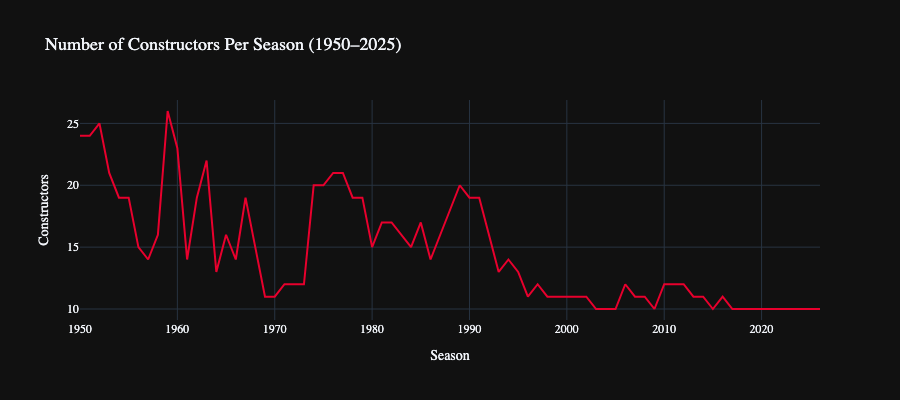

In [4]:
constructors_per_year = df.groupby('Year')['Constructor'].nunique().reset_index(name='Count')

fig = px.line(
    constructors_per_year, x='Year', y='Count',
    title='Number of Constructors Per Season (1950–2025)',
    labels={'Count': 'Constructors', 'Year': 'Season'},
    template='plotly_dark'
)
fig.update_traces(line=dict(color='#e8002d', width=2))
fig.update_layout(
    font=dict(family='DM Sans'),
    title_font_size=18,
    height=400
)
fig.show()

## 4. Top 15 Constructors by All-Time Wins

The all-time win leaderboard reveals which teams have consistently been at the front of the grid across multiple eras.

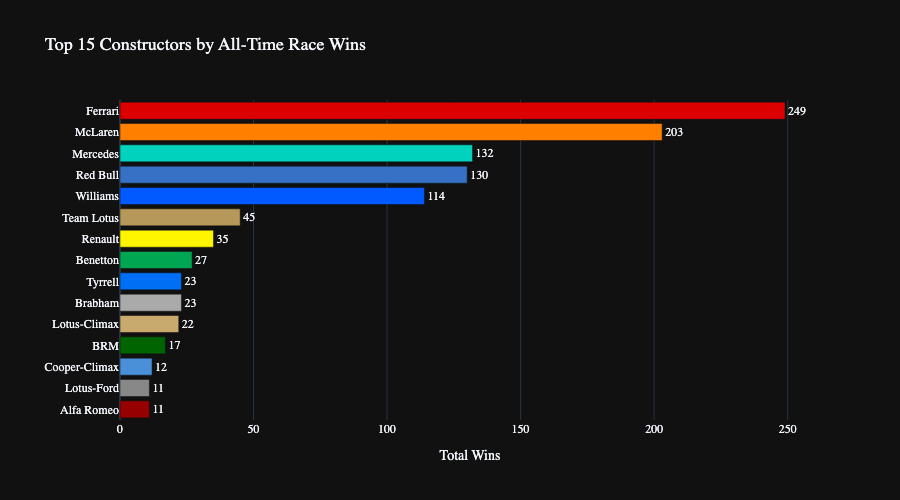

In [5]:
top_wins = df.groupby('Constructor')['Win'].sum().nlargest(15).reset_index()
top_wins = top_wins.sort_values('Win')

# Constructor brand colors
TEAM_COLORS = {
    'Ferrari': '#dc0000', 'McLaren': '#ff8000', 'Mercedes': '#00d2be',
    'Red Bull': '#3671c6', 'Williams': '#005aff', 'Renault': '#fff500',
    'Benetton': '#00a651', 'Team Lotus': '#b5985a', 'Lotus-Climax': '#c8a96e',
    'Brabham': '#aaaaaa', 'Tyrrell': '#006ef5', 'BRM': '#006400',
    'Cooper-Climax': '#4a90d9', 'Alfa Romeo': '#960000', 'Brawn': '#f5f5f5',
    'Vanwall': '#005f3c', 'Maserati': '#c0392b', 'Matra-Ford': '#002395',
    'Alpine': '#0090ff', 'Lotus F1': '#e5c158',
}
colors = [TEAM_COLORS.get(c, '#888888') for c in top_wins['Constructor']]

fig = go.Figure(go.Bar(
    x=top_wins['Win'], y=top_wins['Constructor'],
    orientation='h',
    marker_color=colors,
    text=top_wins['Win'], textposition='outside'
))
fig.update_layout(
    title='Top 15 Constructors by All-Time Race Wins',
    xaxis_title='Total Wins', yaxis_title='',
    template='plotly_dark', height=500,
    font=dict(family='DM Sans'), title_font_size=18,
    margin=dict(l=120)
)
fig.show()

## 5. Top 15 Constructors by All-Time Points

Points tell a different story than wins — the scoring system has changed dramatically over the decades (from 8 points for a win in the 1950s to 25+ today). Teams active in the modern era accumulate far more points per season.

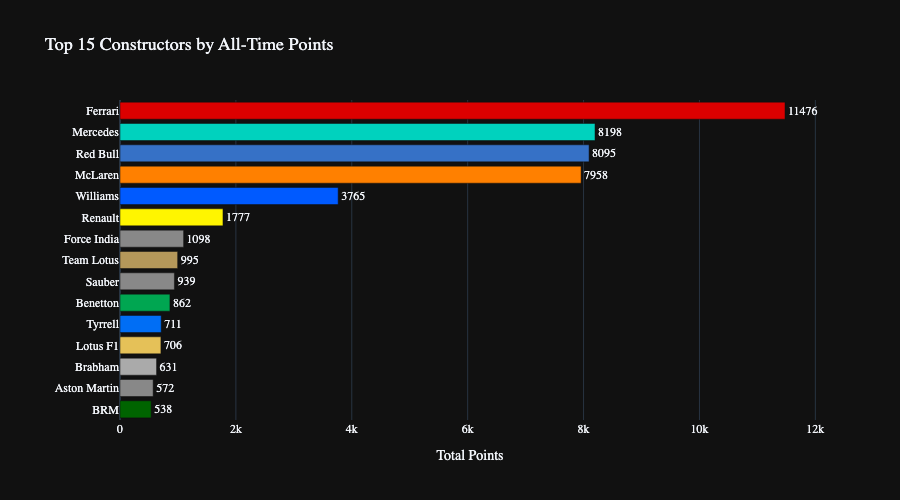

In [6]:
top_pts = df.groupby('Constructor')['Points'].sum().nlargest(15).reset_index()
top_pts = top_pts.sort_values('Points')
colors_pts = [TEAM_COLORS.get(c, '#888888') for c in top_pts['Constructor']]

fig = go.Figure(go.Bar(
    x=top_pts['Points'], y=top_pts['Constructor'],
    orientation='h',
    marker_color=colors_pts,
    text=top_pts['Points'].round(0).astype(int), textposition='outside'
))
fig.update_layout(
    title='Top 15 Constructors by All-Time Points',
    xaxis_title='Total Points', yaxis_title='',
    template='plotly_dark', height=500,
    font=dict(family='DM Sans'), title_font_size=18,
    margin=dict(l=120)
)
fig.show()

## 6. Points Distribution — The Long Tail

Most constructors score very few points in any given season. Only a handful of teams each year are truly competitive — the rest are making up the numbers.

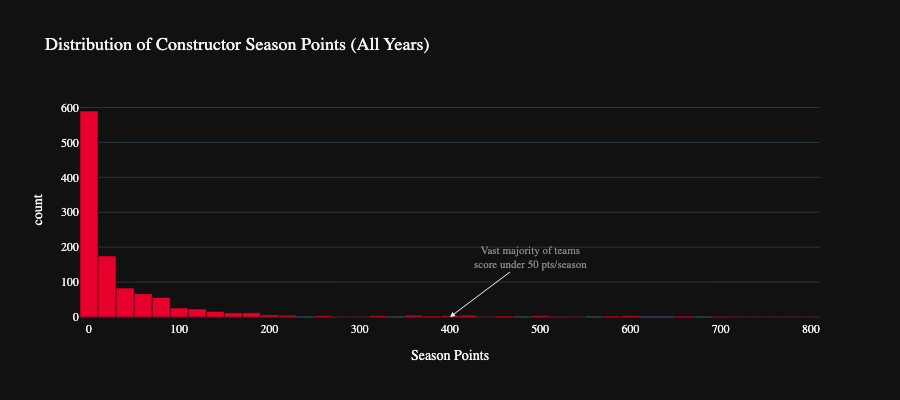

In [7]:
fig = px.histogram(
    df, x='Points', nbins=60,
    title='Distribution of Constructor Season Points (All Years)',
    labels={'Points': 'Season Points', 'count': 'Frequency'},
    template='plotly_dark'
)
fig.update_traces(marker_color='#e8002d', marker_line_color='#0a0a0a', marker_line_width=0.5)
fig.update_layout(
    font=dict(family='DM Sans'), title_font_size=18, height=400,
    annotations=[dict(
        x=400, y=0, xref='x', yref='y',
        text='Vast majority of teams<br>score under 50 pts/season',
        showarrow=True, arrowhead=2, ax=80, ay=-60,
        font=dict(size=11, color='#888888')
    )]
)
fig.show()

---
## Visualization Prototyping

The following visualizations progress from raw exploration to the final chart forms.

## 7. Line Chart — Yearly Points for Top 6 Constructors

Before stacking, let's see each constructor's trajectory individually. This reveals the raw signal — when each team peaked and declined.

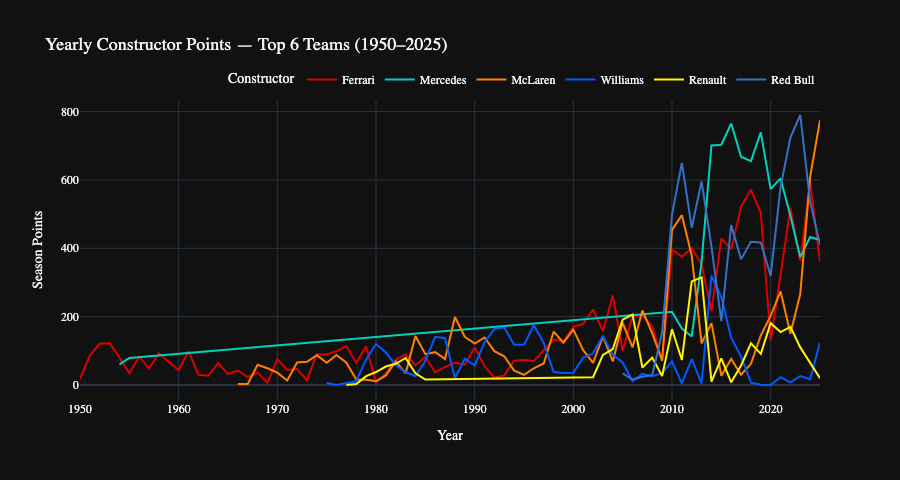

In [8]:
TOP_6 = ['Ferrari', 'McLaren', 'Mercedes', 'Red Bull', 'Williams', 'Renault']
TOP_6_COLORS = {'Ferrari': '#dc0000', 'McLaren': '#ff8000', 'Mercedes': '#00d2be',
                'Red Bull': '#3671c6', 'Williams': '#005aff', 'Renault': '#fff500'}

# Merge Alpine and Lotus F1 into Renault (same lineage)
df_mapped = df.copy()
df_mapped['Constructor'] = df_mapped['Constructor'].replace({'Alpine': 'Renault', 'Lotus F1': 'Renault'})

top6_df = df_mapped[df_mapped['Constructor'].isin(TOP_6) & (df_mapped['Year'] <= 2025)]
top6_yearly = top6_df.groupby(['Year', 'Constructor'])['Points'].sum().reset_index()

fig = px.line(
    top6_yearly, x='Year', y='Points', color='Constructor',
    color_discrete_map=TOP_6_COLORS,
    title='Yearly Constructor Points — Top 6 Teams (1950–2025)',
    labels={'Points': 'Season Points'},
    template='plotly_dark'
)
fig.update_layout(
    font=dict(family='DM Sans'), title_font_size=18, height=480,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.show()

## 8. Stacked Area Chart — Constructor Points Over Time

The stacked area shows how total constructor points are distributed among the top 6 teams over time — revealing which team dominated each era.

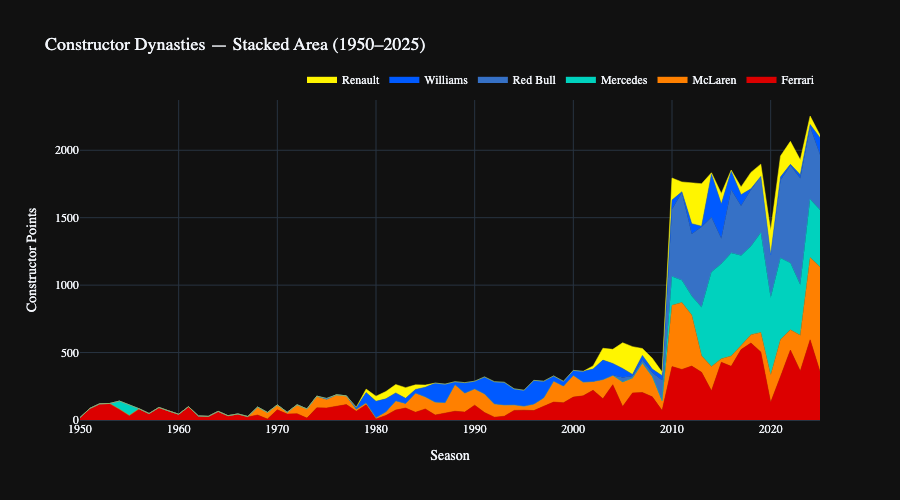

In [9]:
# Pivot: rows=Year, columns=Constructor, values=Points
pivot = top6_yearly.pivot(index='Year', columns='Constructor', values='Points').fillna(0)
pivot = pivot.reindex(columns=TOP_6)  # consistent order

fig = go.Figure()
for team in TOP_6:
    fig.add_trace(go.Scatter(
        x=pivot.index, y=pivot[team],
        mode='lines', name=team,
        stackgroup='one',
        line=dict(width=0.5, color=TOP_6_COLORS[team]),
        fillcolor=TOP_6_COLORS[team],
    ))

fig.update_layout(
    title='Constructor Dynasties — Stacked Area (1950–2025)',
    xaxis_title='Season', yaxis_title='Constructor Points',
    template='plotly_dark', height=500,
    font=dict(family='DM Sans'), title_font_size=18,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    hovermode='x unified'
)
fig.show()

## 9. Stacked Area with Era Annotations

Adding named F1 eras as vertical bands — Eras are defined by regulation changes and dominant teams.

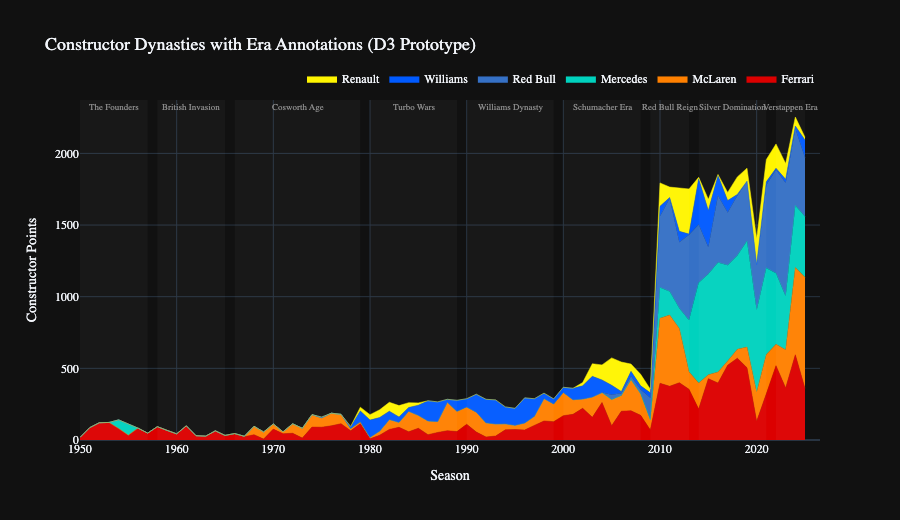

In [10]:
# F1 eras (matching the D3 theme.js)
ERAS = [
    {'start': 1950, 'end': 1957, 'label': 'The Founders'},
    {'start': 1958, 'end': 1965, 'label': 'British Invasion'},
    {'start': 1966, 'end': 1979, 'label': 'Cosworth Age'},
    {'start': 1980, 'end': 1989, 'label': 'Turbo Wars'},
    {'start': 1990, 'end': 1999, 'label': 'Williams Dynasty'},
    {'start': 2000, 'end': 2008, 'label': 'Schumacher Era'},
    {'start': 2009, 'end': 2013, 'label': 'Red Bull Reign'},
    {'start': 2014, 'end': 2021, 'label': 'Silver Domination'},
    {'start': 2022, 'end': 2025, 'label': 'Verstappen Era'},
]

fig = go.Figure()

# Era background bands
for era in ERAS:
    fig.add_vrect(
        x0=era['start'], x1=era['end'],
        fillcolor='rgba(255,255,255,0.03)', line_width=0,
        annotation_text=era['label'],
        annotation_position='top',
        annotation=dict(font_size=9, font_color='#888888')
    )

# Stacked areas
for team in TOP_6:
    fig.add_trace(go.Scatter(
        x=pivot.index, y=pivot[team],
        mode='lines', name=team,
        stackgroup='one',
        line=dict(width=0.5, color=TOP_6_COLORS[team]),
        fillcolor=TOP_6_COLORS[team],
    ))

fig.update_layout(
    title='Constructor Dynasties with Era Annotations (D3 Prototype)',
    xaxis_title='Season', yaxis_title='Constructor Points',
    template='plotly_dark', height=520,
    font=dict(family='DM Sans'), title_font_size=18,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    hovermode='x unified'
)
fig.show()

## 10. Dominance Index — Win Share by Top Team Each Year

For each season, we calculate what percentage of total wins the most successful team captured. A high % means one team dominated; a low % means the championship was wide open. 

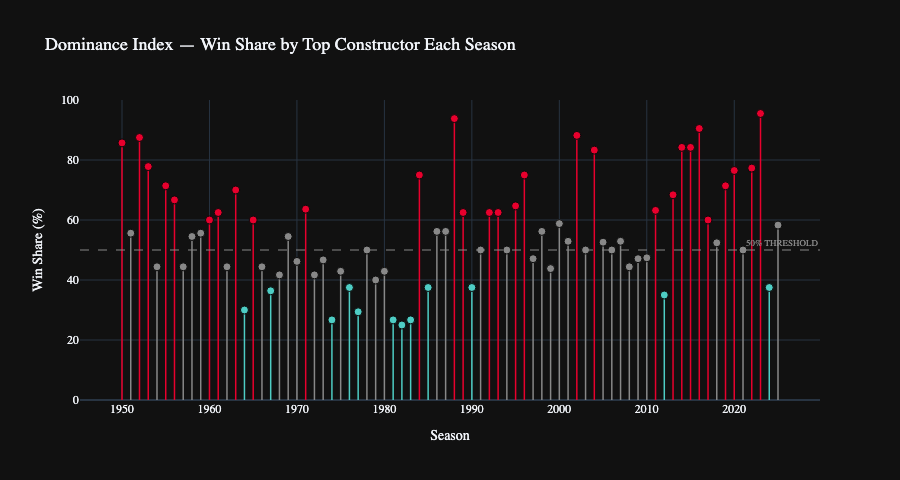

In [11]:
# Calculate dominance % per year
yearly_wins = df[df['Year'] <= 2025].groupby('Year').agg(
    total_wins=('Win', 'sum'),
    max_wins=('Win', 'max')
).reset_index()

# Find which team had the max wins each year
top_team_per_year = df[df['Year'] <= 2025].loc[
    df[df['Year'] <= 2025].groupby('Year')['Win'].idxmax()
][['Year', 'Constructor']].rename(columns={'Constructor': 'TopTeam'})

dominance = yearly_wins.merge(top_team_per_year, on='Year')
dominance['pct'] = (dominance['max_wins'] / dominance['total_wins'] * 100).round(1)
dominance = dominance[dominance['total_wins'] > 0]

# Color gradient: green (competitive) → gray → red (dominant)
def dom_color(pct):
    if pct >= 60:
        return '#e8002d'
    elif pct >= 40:
        return '#888888'
    else:
        return '#4ecdc4'

dominance['color'] = dominance['pct'].apply(dom_color)

fig = go.Figure()

# Stems
for _, row in dominance.iterrows():
    fig.add_trace(go.Scatter(
        x=[row['Year'], row['Year']], y=[0, row['pct']],
        mode='lines', line=dict(color=row['color'], width=1.5),
        showlegend=False, hoverinfo='skip'
    ))

# Dots
fig.add_trace(go.Scatter(
    x=dominance['Year'], y=dominance['pct'],
    mode='markers',
    marker=dict(size=8, color=dominance['color'], line=dict(color='#0a0a0a', width=1)),
    text=dominance.apply(lambda r: f"{r['Year']}: {r['TopTeam']} — {r['pct']}%", axis=1),
    hoverinfo='text',
    name='Dominance %'
))

# 50% threshold line
fig.add_hline(y=50, line_dash='dash', line_color='#888888', line_width=1,
              annotation_text='50% THRESHOLD', annotation_position='top right',
              annotation_font=dict(size=9, color='#888888'))

fig.update_layout(
    title='Dominance Index — Win Share by Top Constructor Each Season',
    xaxis_title='Season', yaxis_title='Win Share (%)',
    yaxis=dict(range=[0, 100]),
    template='plotly_dark', height=480,
    font=dict(family='DM Sans'), title_font_size=18,
    showlegend=False
)
fig.show()

## 11. Most Dominant vs Most Competitive Seasons

Filtering the dominance index to show the extremes — seasons where one team was untouchable, and seasons where the championship was wide open. 

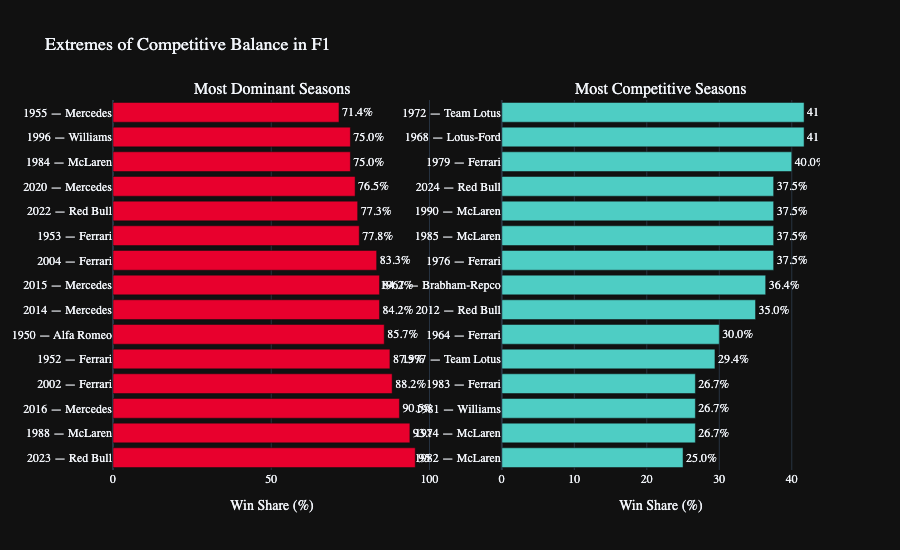

In [12]:
most_dominant = dominance.nlargest(15, 'pct')
most_competitive = dominance.nsmallest(15, 'pct')

fig = make_subplots(rows=1, cols=2, subplot_titles=('Most Dominant Seasons', 'Most Competitive Seasons'))

# Dominant
fig.add_trace(go.Bar(
    y=most_dominant['Year'].astype(str) + ' — ' + most_dominant['TopTeam'],
    x=most_dominant['pct'],
    orientation='h',
    marker_color='#e8002d',
    text=most_dominant['pct'].astype(str) + '%',
    textposition='outside',
    name='Dominant'
), row=1, col=1)

# Competitive
fig.add_trace(go.Bar(
    y=most_competitive['Year'].astype(str) + ' — ' + most_competitive['TopTeam'],
    x=most_competitive['pct'],
    orientation='h',
    marker_color='#4ecdc4',
    text=most_competitive['pct'].astype(str) + '%',
    textposition='outside',
    name='Competitive'
), row=1, col=2)

fig.update_layout(
    title='Extremes of Competitive Balance in F1',
    template='plotly_dark', height=550,
    font=dict(family='DM Sans'), title_font_size=18,
    showlegend=False
)
fig.update_xaxes(title_text='Win Share (%)', row=1, col=1)
fig.update_xaxes(title_text='Win Share (%)', row=1, col=2)
fig.show()

## 12. Heatmap — Constructor Dominance by Decade

A high-level view showing how wins were distributed across the top 10 constructors in each decade. Dark red cells indicate era dominance.

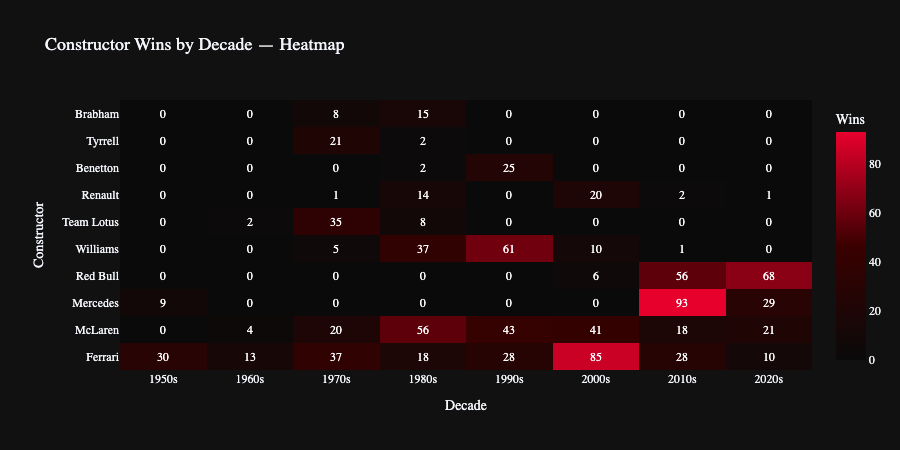

In [13]:
# Create decade column
df_heat = df_mapped[df_mapped['Year'] <= 2025].copy()
df_heat['Decade'] = (df_heat['Year'] // 10 * 10).astype(str) + 's'

# Top 10 constructors by total wins
top10 = df_heat.groupby('Constructor')['Win'].sum().nlargest(10).index.tolist()

heat_data = df_heat[df_heat['Constructor'].isin(top10)].groupby(
    ['Constructor', 'Decade']
)['Win'].sum().reset_index()

heat_pivot = heat_data.pivot(index='Constructor', columns='Decade', values='Win').fillna(0)
# Order constructors by total wins
heat_pivot = heat_pivot.loc[heat_pivot.sum(axis=1).sort_values(ascending=True).index]

fig = px.imshow(
    heat_pivot.values,
    labels=dict(x='Decade', y='Constructor', color='Wins'),
    x=heat_pivot.columns.tolist(),
    y=heat_pivot.index.tolist(),
    color_continuous_scale=['#0a0a0a', '#3a0000', '#e8002d'],
    title='Constructor Wins by Decade — Heatmap',
    template='plotly_dark',
    aspect='auto'
)
fig.update_layout(
    font=dict(family='DM Sans'), title_font_size=18, height=450,
    margin=dict(l=120)
)
fig.update_traces(text=heat_pivot.values.astype(int), texttemplate='%{text}')
fig.show()

## 13. Win Share Treemap — All-Time Proportion of Victories

A treemap showing how the total pool of F1 race wins is divided among constructors. Ferrari's visual dominance is immediately apparent.

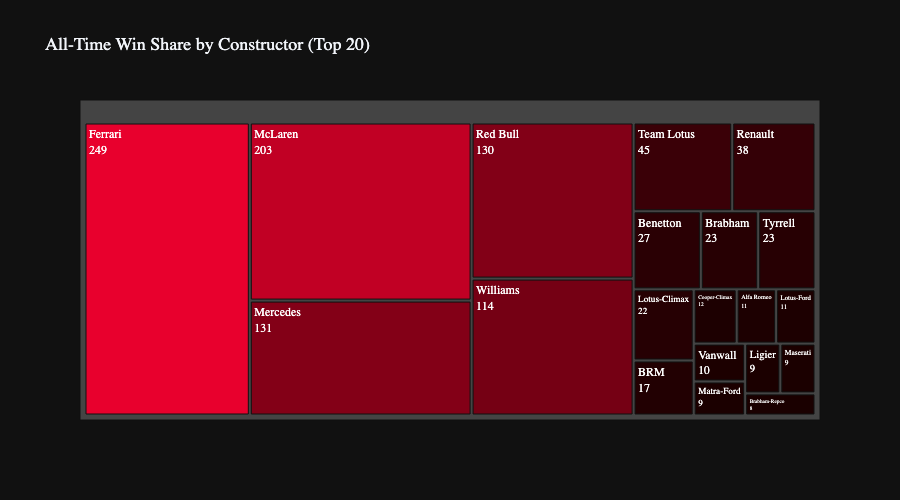

In [14]:
win_share = df_mapped[df_mapped['Year'] <= 2025].groupby('Constructor')['Win'].sum().reset_index()
win_share = win_share[win_share['Win'] > 0].sort_values('Win', ascending=False)

# Color mapping
win_share['Color'] = win_share['Constructor'].map(TOP_6_COLORS).fillna('#888888')

fig = px.treemap(
    win_share.head(20), path=['Constructor'], values='Win',
    title='All-Time Win Share by Constructor (Top 20)',
    color='Win',
    color_continuous_scale=['#1a0000', '#e8002d'],
    template='plotly_dark'
)
fig.update_layout(
    font=dict(family='DM Sans'), title_font_size=18, height=500,
    coloraxis_showscale=False
)
fig.update_traces(textinfo='label+value', textfont_size=12)
fig.show()

---
## Key Findings

1. **Ferrari is the all-time leader** in both wins and points, but their dominance has waned since the Schumacher era ended in 2008.
2. **Points inflation** from scoring system changes means raw points comparisons across eras are misleading — wins are a more stable metric.
3. **The sport alternates between dominant eras and competitive chaos** — regulation changes are the great equalizer (1982 had 7 different winners; 2023 had Red Bull winning 21/22).
4. **The stacked area chart** clearly shows how dynasties rise and fall — Ferrari's red dominance gives way to Mercedes teal, then Red Bull blue.
5. **The modern era (2010+)** concentrates far more points at the top, making the stacked area visually dominated by recent years.

Key takeaways: the era annotations and the dominance lollipop chart as a complementary view.